<font color = brown size = 5><b> 1) IMPORTING LIBRARIES </b></font>

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline

<font color = blue size = 5><b>2) IMPORTING AND PREPARING DATASET</b></font>

In [75]:
df_apr = pd.read_csv("C:/Users/prp2k/Desktop/BITS MBA BA/Semester 2/Predictive Analytics/Project/archive (2)/uber-raw-data-apr14.csv")
df_may = pd.read_csv("C:/Users/prp2k/Desktop/BITS MBA BA/Semester 2/Predictive Analytics/Project/archive (2)/uber-raw-data-may14.csv")
df_jun = pd.read_csv("C:/Users/prp2k/Desktop/BITS MBA BA/Semester 2/Predictive Analytics/Project/archive (2)/uber-raw-data-jun14.csv")
df_jul = pd.read_csv("C:/Users/prp2k/Desktop/BITS MBA BA/Semester 2/Predictive Analytics/Project/archive (2)/uber-raw-data-jul14.csv")
df_aug = pd.read_csv("C:/Users/prp2k/Desktop/BITS MBA BA/Semester 2/Predictive Analytics/Project/archive (2)/uber-raw-data-aug14.csv")
df_sep = pd.read_csv("C:/Users/prp2k/Desktop/BITS MBA BA/Semester 2/Predictive Analytics/Project/archive (2)/uber-raw-data-sep14.csv")

data = pd.concat([df_apr,df_may,df_jun,df_jul,df_aug,df_sep],ignore_index=True)
print("Data Preparation Success")

Data Preparation Success


<font color = brown size = 5><b> 3) READING DATASET </b></font>

In [76]:
a = data.info()
b = data.head()

print(a,"\n\n\n",b)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date/Time  object 
 1   Lat        float64
 2   Lon        float64
 3   Base       object 
dtypes: float64(2), object(2)
memory usage: 138.4+ MB
None 


           Date/Time      Lat      Lon    Base
0  4/1/2014 0:11:00  40.7690 -73.9549  B02512
1  4/1/2014 0:17:00  40.7267 -74.0345  B02512
2  4/1/2014 0:21:00  40.7316 -73.9873  B02512
3  4/1/2014 0:28:00  40.7588 -73.9776  B02512
4  4/1/2014 0:33:00  40.7594 -73.9722  B02512


<font color = blue size = 5><b> 4) DATASET CLEAN AND PREPROCESS </b></font>

In [77]:
data.rename(columns={
    'Date/Time': 'datetime', 
    'Lat': 'lat',
    'Lon': 'lon',
    'Base': 'base'
}, inplace=True)  

data['datetime'] = pd.to_datetime(data['datetime'], format='%m/%d/%Y %H:%M:%S')

c = data.info()
d = data.head()

print(c,"\n\n\n",d)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column    Dtype         
---  ------    -----         
 0   datetime  datetime64[ns]
 1   lat       float64       
 2   lon       float64       
 3   base      object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 138.4+ MB
None 


              datetime      lat      lon    base
0 2014-04-01 00:11:00  40.7690 -73.9549  B02512
1 2014-04-01 00:17:00  40.7267 -74.0345  B02512
2 2014-04-01 00:21:00  40.7316 -73.9873  B02512
3 2014-04-01 00:28:00  40.7588 -73.9776  B02512
4 2014-04-01 00:33:00  40.7594 -73.9722  B02512


<font color = brown size = 5><b> 5) FEATURE ENGINEERING </b></font>

In [78]:
data['hour'] = data['datetime'].dt.hour
data['day_of_week'] = data['datetime'].dt.dayofweek
data['is_weekend'] = data['day_of_week'].isin([5,6]).astype(int)

coords = data[['lat', 'lon']].values
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10).fit(coords)
data['location_cluster'] = kmeans.labels_

hourly_demand = data.groupby(['hour', 'day_of_week', 'is_weekend', 'location_cluster']).size().reset_index(name='demand')

<font color = blue size = 5><b> 6) FEATURE OPTIMIZATION </b></font>

In [79]:
X = hourly_demand[['hour', 'day_of_week', 'location_cluster', 'is_weekend']]
y = hourly_demand['demand']

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

selector = SelectKBest(f_regression, k=8)
X_selected = selector.fit_transform(X_poly, y)

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<font color = brown size = 5><b> 7) TRAIN MODELS </b></font>

In [80]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=0.5),
    'Lasso Regression': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05),
    'Support Vector Regression': SVR(C=1.0, epsilon=0.2)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

<font color = blue size = 5><b> 8) EVALUATE MODELS </b></size>

In [81]:
results_df = pd.DataFrame(results).T
results = results_df.sort_values('RMSE')
print("\nModel Performance Comparison:")
results # From this we can see that Random Forest is best model to proceed


Model Performance Comparison:


,MAE,RMSE,R2
Random Forest,202.610808,482.942885,0.968034
XGBoost,267.377655,505.235078,0.965015
ElasticNet,1607.446945,2335.141496,0.252659
Ridge Regression,1613.910127,2335.559714,0.252392
Lasso Regression,1614.417690,2335.667548,0.252323
Linear Regression,1614.430951,2335.670457,0.252321
Support Vector Regression,1579.217570,2945.487568,-0.189068


<font color = brown size = 5><b>9) VISUALIZATION </b></font>

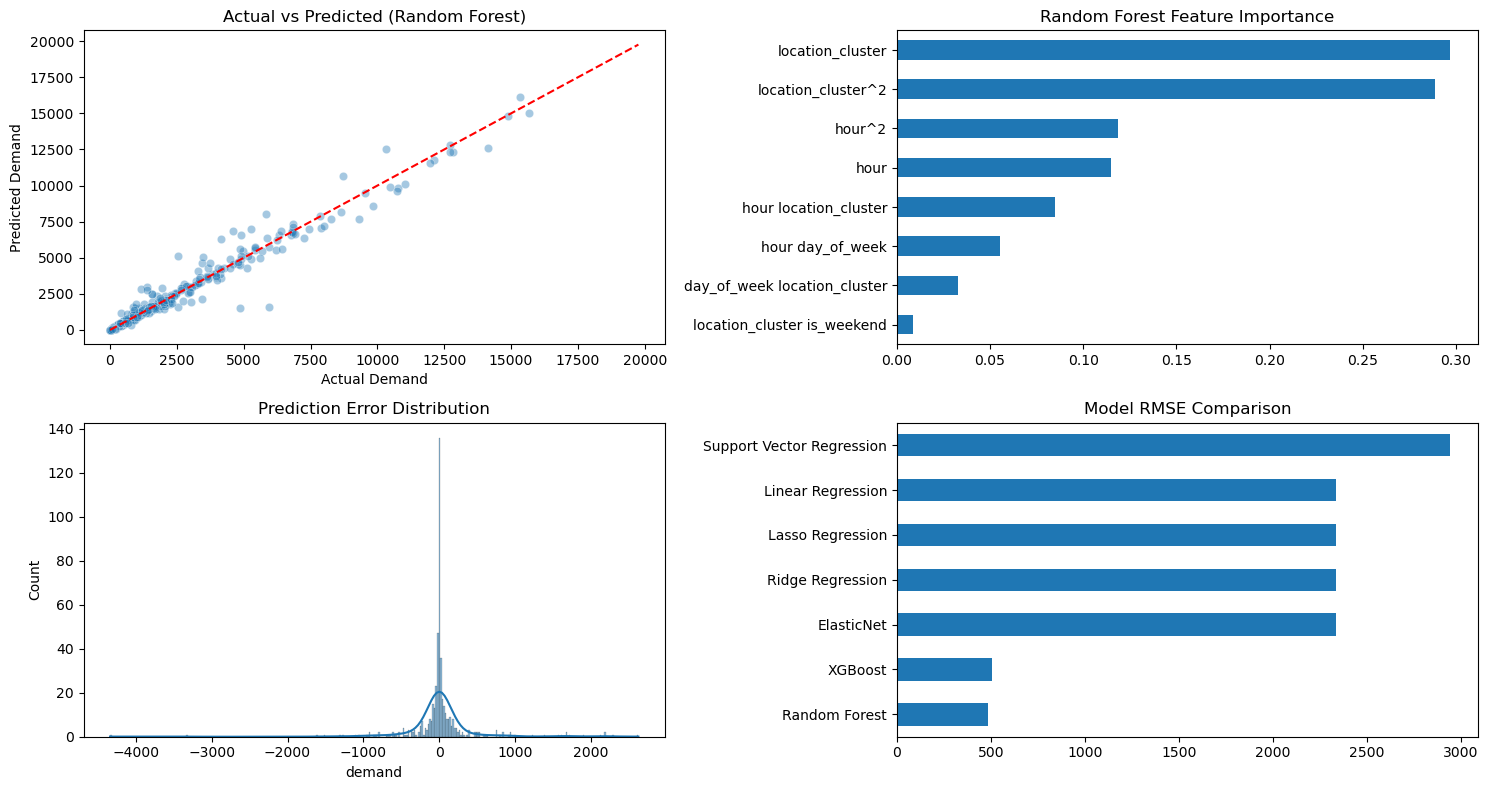

In [82]:
plt.figure(figsize=(15, 8))

# Actual vs Predicted (Best Model)
best_model = results_df['RMSE'].idxmin()
y_pred_best = models[best_model].predict(X_test_scaled)

plt.subplot(2, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.4)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title(f'Actual vs Predicted ({best_model})')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')

# Feature Importance (Tree-based Models)
plt.subplot(2, 2, 2)
feature_names = poly.get_feature_names_out()[selector.get_support()]
rf_importance = models['Random Forest'].feature_importances_
pd.Series(rf_importance, index=feature_names).sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')

# Error Distribution
plt.subplot(2, 2, 3)
errors = y_pred_best - y_test
sns.histplot(errors, kde=True)
plt.title('Prediction Error Distribution')

# Model Comparison
plt.subplot(2, 2, 4)
results_df['RMSE'].sort_values().plot(kind='barh')
plt.title('Model RMSE Comparison')

plt.tight_layout()
plt.show()

<font color = blue size = 5><b> 10) FORECASTING</b></font>

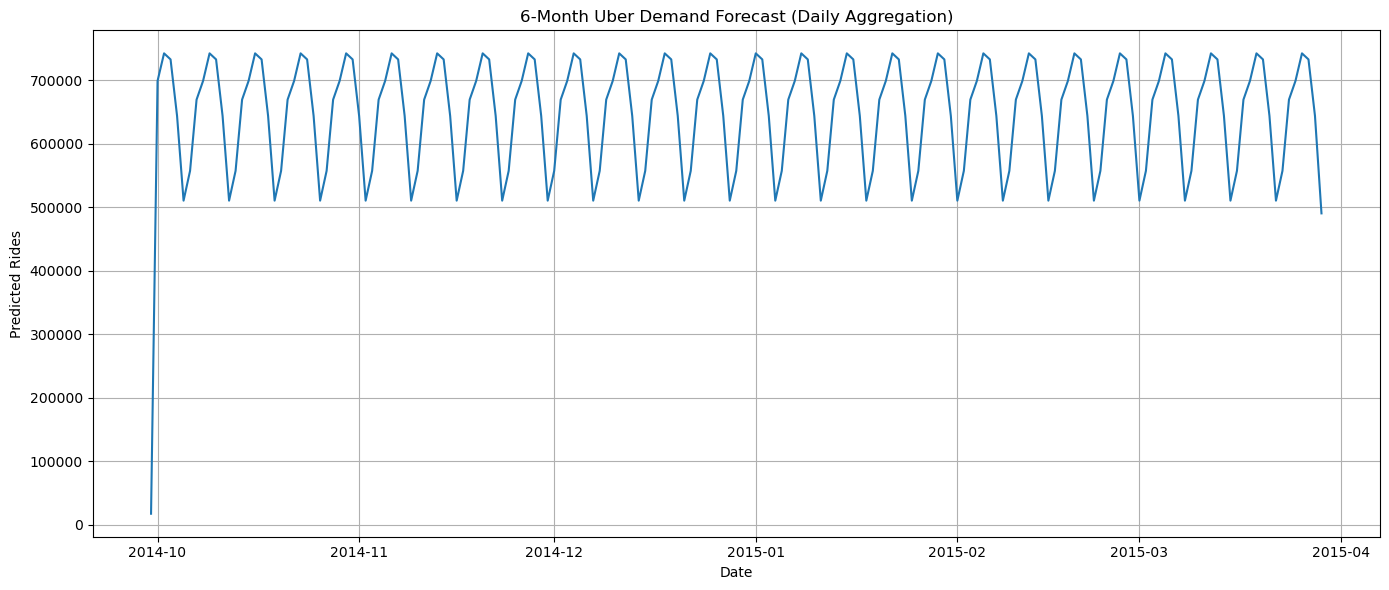

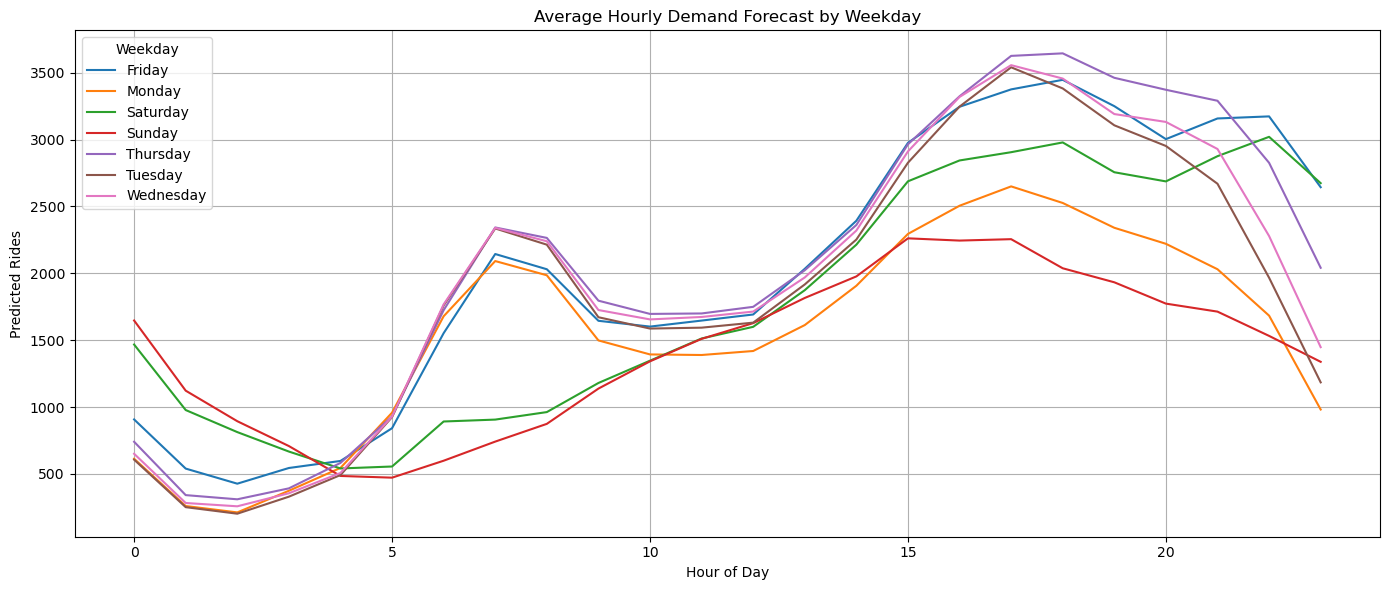

In [83]:
def forecast(data, models, poly, selector, scaler, n_clusters=15):
    # Install xgboost if missing
    try:
        from xgboost import XGBRegressor
    except ImportError:
        !pip install xgboost --quiet
        from xgboost import XGBRegressor

    # Generate future dates
    last_date = data['datetime'].max()
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(hours=1),
        periods=24*30*6,  # 6 months of hourly data
        freq='h'
    )
    
    # Create future feature matrix with CORRECT COLUMN ORDER
    future_df = pd.DataFrame({'datetime': future_dates})
    future_df['hour'] = future_df['datetime'].dt.hour
    future_df['day_of_week'] = future_df['datetime'].dt.dayofweek
    future_df['is_weekend'] = future_df['day_of_week'].isin([5,6]).astype(int)
    
    # Replicate for all location clusters
    future_df = future_df.loc[future_df.index.repeat(n_clusters)].reset_index(drop=True)
    future_df['location_cluster'] = np.tile(np.arange(n_clusters), len(future_dates))
    
    # Maintain training feature order: ['hour', 'day_of_week', 'location_cluster', 'is_weekend']
    feature_order = ['hour', 'day_of_week', 'location_cluster', 'is_weekend']
    X_future = future_df[feature_order]
    
    # Feature transformations (same order as training)
    try:
        X_future_poly = poly.transform(X_future)
        X_future_selected = selector.transform(X_future_poly)
        X_future_scaled = scaler.transform(X_future_selected)
    except ValueError as e:
        print("Feature mismatch error! Verify:")
        print(f"Training features: {poly.feature_names_in_}")
        print(f"Forecast features: {X_future.columns.tolist()}")
        raise e
    
    # Get best model
    results_df = pd.DataFrame(models).T
    best_model_name = results['RMSE'].idxmin()
    best_model = models[best_model_name]
    
    # Predict demand
    future_df['predicted_demand'] = best_model.predict(X_future_scaled)
    
    # Create visualizations
    plot_forecasts(future_df)
    
    return future_df

def plot_forecasts(future_df):
    # Daily demand
    future_daily = future_df.groupby(pd.Grouper(key='datetime', freq='D'))['predicted_demand'].sum().reset_index()
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(x='datetime', y='predicted_demand', data=future_daily)
    plt.title('6-Month Uber Demand Forecast (Daily Aggregation)')
    plt.xlabel('Date')
    plt.ylabel('Predicted Rides')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Weekly pattern
    future_df['weekday'] = future_df['datetime'].dt.day_name()
    weekday_demand = future_df.groupby(['hour', 'weekday'])['predicted_demand'].mean().reset_index()
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(x='hour', y='predicted_demand', hue='weekday', data=weekday_demand)
    plt.title('Average Hourly Demand Forecast by Weekday')
    plt.xlabel('Hour of Day')
    plt.ylabel('Predicted Rides')
    plt.legend(title='Weekday')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # # Cluster heatmap
    # cluster_demand = future_df.groupby(['location_cluster', pd.Grouper(key='datetime', freq='W-MON')])['predicted_demand'].sum().unstack()
    
    # plt.figure(figsize=(16, 8))
    # sns.heatmap(cluster_demand, cmap='YlGnBu', cbar_kws={'label': 'Weekly Rides'})
    # plt.title('Weekly Demand Forecast by Location Cluster')
    # plt.xlabel('Week Starting')
    # plt.ylabel('Location Cluster')
    # plt.tight_layout()
    # plt.show()

# Run forecasting and visualization
forecast_df = forecast(data, models, poly, selector, scaler)
